# SQL-IDS: Tek Notebook Akisi

Bu notebook, SQL Injection tespiti icin uctan uca bir makine ogrenmesi akisini
moduler olmayan ve sinif (class) icermeyen bir yapiyla sunar.

## 1) Hazirlik ve Veri Temizligi

In [1]:
import os
import re
import pickle
from urllib.parse import unquote_plus

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Veri yukleme ve temizlik

- `dataset.csv` okunur.
- `Unnamed: 2` ve `Unnamed: 3` kolonlari kaldirilir.
- `Sentence` sutunundaki bos (`NaN`) satirlar silinir.
- Veri string formata cevrilir.

In [2]:
DATASET_PATH = "./data/SQLiV3.csv"
#DATASET_PATH ="./cleaned_sql_data.csv" #made from Dataset_EDA
# Veriyi oku
df = pd.read_csv(DATASET_PATH)

# Istenen kolonlari kaldir (varsa)
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3"], errors="ignore")

# Sentence sutunu kontrolu
if "Sentence" not in df.columns:
    raise ValueError("Dataset icinde 'Sentence' kolonu bulunamadi.")

# Sentence NaN satirlarini sil
df = df.dropna(subset=["Sentence"]).copy()

# Tum veriyi string formata cevir
df = df.astype(str)

# Label kolonunu bul
possible_label_cols = ["Label", "label", "Class", "class", "Target", "target"]
label_col = next((col for col in possible_label_cols if col in df.columns), None)
if label_col is None:
    raise ValueError("Label kolonu bulunamadi. Beklenen kolonlardan biri olmali.")

print("Veri boyutu:", df.shape)
print("Kullanilan label kolonu:", label_col)
df.head()

Veri boyutu: (30904, 2)
Kullanilan label kolonu: Label


,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


## 2) On Isleme ve Vektorlestirme

- URL decoding ve kucuk harf donusumu uygulanir.
- Veri %80 egitim, %20 test olarak ayrilir.
- `TfidfVectorizer` sadece egitim verisinde `fit` edilir.

In [3]:
def clean_text(text):
    """URL decode + lowercase + basic whitespace cleanup."""
    text = unquote_plus(str(text))
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


# Metin temizligi
df["clean_text"] = df["Sentence"].apply(clean_text)

# Label'i binary formata cevir (0/1)
malicious_labels = {"1", "true", "yes", "sqli", "malicious", "attack"}
df["y"] = df[label_col].str.strip().str.lower().apply(
    lambda x: 1 if x in malicious_labels else 0
)

print(df[["Sentence", "clean_text", "y"]].head())

                                            Sentence  \
0                  " or pg_sleep  (  __TIME__  )  --   
1  create user name identified by pass123 tempora...   
2   AND 1  =  utl_inaddr.get_host_address   (    ...   
3   select * from users where id  =  '1' or @ @1 ...   
4   select * from users where id  =  1 or 1#"  ( ...   

                                          clean_text  y  
0                      " or pg_sleep ( __time__ ) --  1  
1  create user name identified by pass123 tempora...  0  
2  and 1 = utl_inaddr.get_host_address ( ( select...  1  
3  select * from users where id = '1' or @ @1 = 1...  1  
4  select * from users where id = 1 or 1#" ( unio...  1  


### Train-test split ve TF-IDF

In [4]:
X_text = df["clean_text"]
y = df["y"]

# Once split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Sonra vectorizer'i sadece egitimde fit et
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = tfidf_vectorizer.fit_transform(X_train_text)
X_test = tfidf_vectorizer.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (24723, 5000)
X_test shape : (6181, 5000)


## 3) Bireysel Model Egitimi ve Kayit

XGBoost, Random Forest ve SVM modelleri ayri ayri egitilir ve `.pkl` olarak kaydedilir.

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42,
)
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
svm_model = SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=42)

models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{model_name} modeli egitildi.")

XGBoost modeli egitildi.
Random Forest modeli egitildi.
SVM modeli egitildi.


### Modellerin ve TF-IDF nesnesinin kaydedilmesi

In [6]:
os.makedirs("models", exist_ok=True)

with open("models/xgboost_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

with open("models/random_forest_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

with open("models/svm_model.pkl", "wb") as file:
    pickle.dump(svm_model, file)

with open("models/tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf_vectorizer, file)

print("xgboost_model.pkl, random_forest_model.pkl, svm_model.pkl ve tfidf_vectorizer.pkl kaydedildi.")

xgboost_model.pkl, random_forest_model.pkl, svm_model.pkl ve tfidf_vectorizer.pkl kaydedildi.


## 4) Performans Degerlendirmesi

Her model icin confusion matrix ve classification_report ciktilari ekrana yazdirilir.


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3913
           1       1.00      0.98      0.99      2268

    accuracy                           0.99      6181
   macro avg       0.99      0.99      0.99      6181
weighted avg       0.99      0.99      0.99      6181



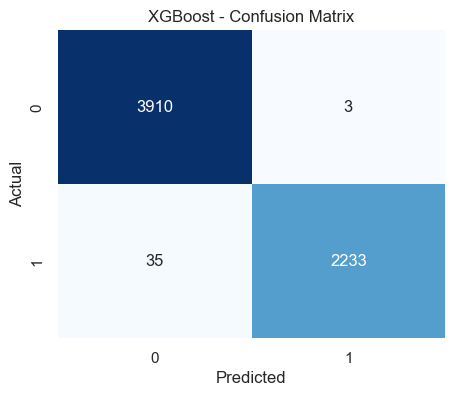


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3913
           1       1.00      0.99      0.99      2268

    accuracy                           0.99      6181
   macro avg       1.00      0.99      0.99      6181
weighted avg       0.99      0.99      0.99      6181



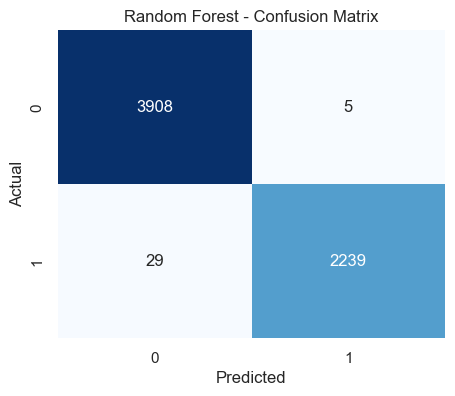


===== SVM =====
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3913
           1       0.99      0.99      0.99      2268

    accuracy                           0.99      6181
   macro avg       0.99      0.99      0.99      6181
weighted avg       0.99      0.99      0.99      6181



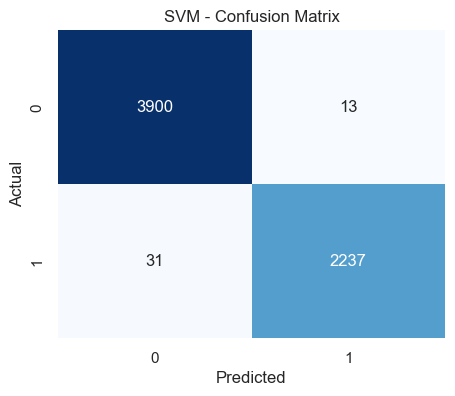

In [7]:
metrics_rows = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    metrics_rows.append({"Model": model_name, "Accuracy": acc, "F1-Score": f1})

    print(f"\n===== {model_name} =====")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 5) Ensemble (Topluluk) Mimarisi

`VotingClassifier` ile XGBoost + Random Forest + SVM modellerinden topluluk modeli kurulur.


===== Ensemble =====
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3913
           1       1.00      0.99      0.99      2268

    accuracy                           0.99      6181
   macro avg       1.00      0.99      0.99      6181
weighted avg       0.99      0.99      0.99      6181



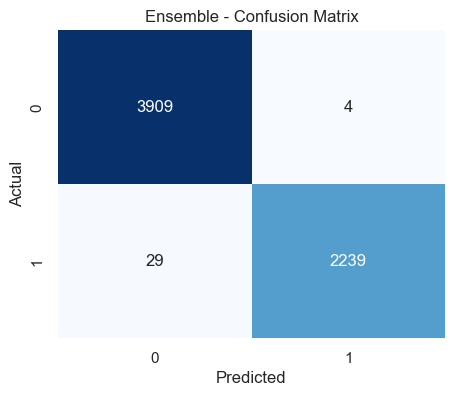

ensemble_model.pkl kaydedildi.


In [8]:
ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model),
        ("svm", svm_model),
    ],
    voting="soft",
)

ensemble_model.fit(X_train, y_train)
y_pred_ensemble = ensemble_model.predict(X_test)

ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_f1 = f1_score(y_test, y_pred_ensemble, zero_division=0)
metrics_rows.append({"Model": "Ensemble", "Accuracy": ensemble_acc, "F1-Score": ensemble_f1})

print("\n===== Ensemble =====")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))

cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ensemble, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

with open("models/ensemble_model.pkl", "wb") as file:
    pickle.dump(ensemble_model, file)

print("ensemble_model.pkl kaydedildi.")

## 6) Gorsellestirme

XGBoost, Random Forest, SVM ve Ensemble modellerinin `Accuracy` ve `F1-Score` degerleri karsilastirilir.

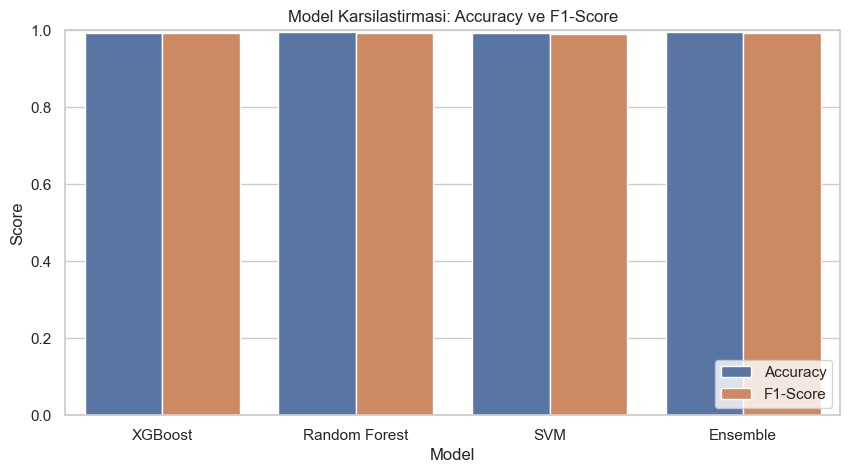

,Model,Accuracy,F1-Score
0,XGBoost,0.993852,0.991563
1,Random Forest,0.994499,0.992465
2,SVM,0.992881,0.990261
3,Ensemble,0.994661,0.992685


In [9]:
metrics_df = pd.DataFrame(metrics_rows)
metrics_melted = metrics_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_melted, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1)
plt.title("Model Karsilastirmasi: Accuracy ve F1-Score")
plt.legend(loc="lower right")
plt.show()

metrics_df

## 7) Farkli Dataset ile Ensemble Testi

Bu bolumde farkli bir dataset kullanilarak yalnizca `full_query` ve `label` kolonlari alinur, kolon adlari `Sentence` ve `Label` olarak yeniden adlandirilir, veri temizlenir ve mevcut `ensemble_model` ile performans analizi yapilir.

In [4]:
NEW_DATASET_PATH = "./data/looking for beter dataset/dataset.csv"
import pandas as pd
import re
from urllib.parse import unquote_plus

# Bu bolum tek basina calistirilirsa clean_text tanimsiz olabilir.
# Bu nedenle fallback olarak burada da fonksiyonu garanti ediyoruz.
if "clean_text" not in globals():
    def clean_text(text):
        text = unquote_plus(str(text))
        text = text.lower().strip()
        text = re.sub(r"\s+", " ", text)
        return text

# 1) Veriyi oku ve sadece istenen kolonlari al
new_df = pd.read_csv(NEW_DATASET_PATH)
new_df = new_df[["full_query", "label"]].copy()
new_df = new_df.rename(columns={"full_query": "Sentence", "label": "Label"})

# 2) Temizlik
new_df = new_df.dropna(subset=["Sentence", "Label"]).copy()
new_df["Sentence"] = new_df["Sentence"].astype(str)
new_df["Label"] = new_df["Label"].astype(str).str.strip().str.lower()

# 3) On isleme
new_df["clean_text"] = new_df["Sentence"].apply(clean_text)
malicious_labels = {"1", "true", "yes", "sqli", "malicious", "attack"}
new_df["y"] = new_df["Label"].apply(lambda x: 1 if x in malicious_labels else 0)

# 4) Vectorizer ile donustur (fit yok, mevcut model/vectorizer ile test)
X_new = tfidf_vectorizer.transform(new_df["clean_text"])
y_new = new_df["y"]

# 5) Ensemble performansi
y_pred_new = ensemble_model.predict(X_new)

print("===== Ensemble (Yeni Dataset) =====")
print(classification_report(y_new, y_pred_new, zero_division=0))

cm_new = confusion_matrix(y_new, y_pred_new)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_new, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Ensemble - Yeni Dataset Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 6) Gorsellestirme: Accuracy, Precision, Recall, F1
report_new = classification_report(y_new, y_pred_new, zero_division=0, output_dict=True)
metrics_new_df = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
        "Score": [
            report_new["accuracy"],
            report_new["1"]["precision"],
            report_new["1"]["recall"],
            report_new["1"]["f1-score"],
        ],
    }
)

plt.figure(figsize=(8, 4))
sns.barplot(data=metrics_new_df, x="Metric", y="Score", hue="Metric", palette="magma", legend=False)
plt.ylim(0, 1)
plt.title("Ensemble Performansi - Yeni Dataset")
plt.ylabel("Score")
plt.show()

metrics_new_df

C:\Users\Mrt\AppData\Local\Temp\ipykernel_19032\2376057677.py:4: DtypeWarning: Columns (0: attack_stage, 1: tamper_method, 2: attack_status, 3: attack_id, 4: attack_technique) have mixed types. Specify dtype option on import or set low_memory=False.
  new_df = pd.read_csv(NEW_DATASET_PATH)


NameError: name 'clean_text' is not defined